# Atelier – Préparation de Données Tabulaires

**Contexte :** une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT
(température, humidité, qualité de l'air, consommation énergétique, occupants, type de bâtiment,
mode de fonctionnement, état de la climatisation).

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Partie 1 – Explorer les données

### 1) Charger les données CSV

Le fichier brut est chargé depuis le sous-dossier `data/`. 


In [ ]:
df=pd.read_csv('../data/smart_building_raw.csv')


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


### 2) Afficher les premières lignes du dataset



In [4]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


### 3) Afficher les dernières lignes du dataset



In [5]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


### 4) Combien d'observations contient le dataset ?

Le nombre d'observations correspond au nombre de lignes du DataFrame.

In [6]:
df.shape[0]

507

### 5) Combien de variables possède le dataset ?

Le nombre de variables correspond au nombre de colonnes.

In [7]:
df.shape[1]


14

### 6) Identifier les variables numériques

Une variable est numérique lorsqu'elle représente une quantité mesurable sur laquelle
les opérations arithmétiques ont un sens (moyenne, écart, somme).


In [13]:
variables_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()

print("Variables numériques détectées par pandas :")
for col in variables_numeriques:
    print(f" {col} ({df[col].dtype})")



Variables numériques détectées par pandas :
 id_mesure (int64)
 temperature (float64)
 humidite (float64)
 co2 (float64)
 occupation (float64)
 consommation_kwh (float64)


**Réponse :** Les variables numériques sont : `temperature`, `humidite`, `co2`, `occupation`,
`consommation_kwh`.

La colonne `id_mesure` est également numérique (`int64`) mais il ne s'agit pas d'une mesure :
c'est un identifiant, donc elle est exclue de cette liste au sens métier.

### 7) Identifier les variables catégorielles

Une variable est catégorielle lorsqu'elle prend un nombre restreint de modalités
qui désignent des groupes, sans relation d'ordre arithmétique.




In [14]:
variables_categorielles = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables catégorielles (type texte) et leur cardinalité :\n")
for col in variables_categorielles:
    modalites = df[col].dropna().unique()
    apercu = ", ".join(map(str, modalites[:8]))
    suite = " ..." if len(modalites) > 8 else ""
    print(f"  - {col:<25} {len(modalites):>3} modalités : {apercu}{suite}")


Variables catégorielles (type texte) et leur cardinalité :

  - date                      500 modalités : 2025-02-13 06:00:00, 2025-03-10 12:00:00, 2025-05-04 00:00:00, 2025-01-19 00:00:00, 2025-04-24 06:00:00, 2025-01-20 00:00:00, 2025-03-21 00:00:00, 2025-02-05 00:00:00 ...
  - batiment                    8 modalités : B8, B7, B5, B6, B3, B4, B2, B1
  - type_batiment              16 modalités : Entrepôt, Bureau, Centre commercial, Université, Hôpital, École, ÉCOLE, ecole ...
  - zone                        4 modalités : A, D, B, C
  - mode_climatisation          7 modalités : Eco, Normal, Boost, normal, BOOST, normale, Normal 
  - etat_systeme                3 modalités : Normal, Alerte, Panne
  - jour_semaine                7 modalités : Jeudi, Lundi, Dimanche, Vendredi, Mercredi, Mardi, Samedi
  - alerte                      2 modalités : Non, Oui


C:\Users\other\AppData\Local\Temp\ipykernel_7404\128847611.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categorielles = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


**Réponse :** Les variables catégorielles sont : `batiment`, `type_batiment`, `zone`,
`mode_climatisation`, `etat_systeme`, `jour_semaine`, `alerte`.


La colonne `date` ressort également dans une détection par type texte (elle a 500 modalités
distinctes), mais elle est **exclue** de la liste des variables catégorielles : il ne s'agit
pas d'une catégorie mais d'une date, encore mal typée (`object` au lieu de `datetime`). Elle
sera traité.

### 8) Identifier les dates


In [22]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    str    
 2   batiment            507 non-null    str    
 3   type_batiment       503 non-null    str    
 4   zone                507 non-null    str    
 5   temperature         495 non-null    float64
 6   humidite            496 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          501 non-null    float64
 9   consommation_kwh    502 non-null    float64
 10  mode_climatisation  502 non-null    str    
 11  etat_systeme        507 non-null    str    
 12  jour_semaine        502 non-null    str    
 13  alerte              507 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 55.6 KB


**Réponse :** La colonne `date` représente la date de mesure. Elle est actuellement de type
`str` (texte), et non de type date : elle devra être convertie plus tard (`pd.to_datetime`)
avant toute analyse chronologique ou tri temporel.

### 9) Identifier les identifiants



In [30]:
print("Valeurs uniques :", df["id_mesure"].nunique())
print("Nombre de lignes :", len(df))
print("Valeurs manquantes :", df["id_mesure"].isna().sum())

Valeurs uniques : 500
Nombre de lignes : 507
Valeurs manquantes : 0


**Réponse :** La colonne `id_mesure` (`int64`, 507 valeurs non nulles) est un identifiant :
elle numérote chaque mesure de façon unique et ne porte aucune information mesurable sur le
bâtiment ou l'environnement. Elle sera exclue des variables explicatives X pour éviter toute
fuite de données.

### 10) Statistiques descriptives

`describe()` fournit d'un coup la moyenne, l'écart-type, le minimum, le maximum et les
quartiles (Q1, médiane, Q3) de chaque variable numérique.


In [46]:
stats = df[variables_numeriques].describe().T

stats = stats.rename(columns={
    "mean": "moyenne",
    "50%": "mediane",
    "min": "minimum",
    "max": "maximum",
    "std": "ecart_type",
    "25%": "Q1",
    "75%": "Q3"
})

stats.round(2)

,count,moyenne,ecart_type,minimum,Q1,mediane,Q3,maximum
id_mesure,507.0,1251.11,144.78,1001.0,1125.50,1252.00,1376.50,1500.0
temperature,495.0,24.15,7.42,-30.0,21.60,24.00,26.00,96.0
humidite,496.0,57.86,16.03,-12.0,49.28,57.55,65.75,160.0
co2,500.0,844.15,582.18,89.0,623.75,787.50,952.00,6000.0
occupation,501.0,44.85,24.95,-20.0,27.00,46.00,61.00,116.0
consommation_kwh,502.0,169.07,53.16,-100.0,136.88,169.80,202.98,336.2


### 11) Y a-t-il des variables potentiellement problématiques ?


In [48]:
df.isna().sum()

id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              11
co2                    7
occupation             6
consommation_kwh       5
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

**Réponse :** Oui, plusieurs variables sont potentiellement problématiques :

- `temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh`, `type_batiment`,
  `mode_climatisation`, `jour_semaine` contiennent des valeurs manquantes (voir tableau ci-dessus).
- `date` est de type texte (`object`) alors qu'elle représente une date : elle devra être
  convertie avec `pd.to_datetime`.
- `id_mesure` est un identifiant unique par ligne : il n'apporte aucune information
  prédictive et devra être exclu des variables explicatives X.

### 12) Rechercher les données incohérentes


**a) à e) Recherche des valeurs incohérentes**

- a) Humidité négative
- b) Humidité > 100%
- c) Température extrêmement élevée
- d)
- e) Consommation négative

In [ ]:
print("a) Humidité < 0 :", (df["humidite"] < 0).sum())
print("b) Humidité > 100 :", (df["humidite"] > 100).sum())
print("c) Température > 60°C :", (df["temperature"] > 60).sum())
print("d")
print("e) Consommation négative :", (df["consommation_kwh"] < 0).sum())

a) Humidité < 0 : 3
b) Humidité > 100 : 7
c) Température > 60°C : 4
d
e) Consommation négative : 4


**f) Transformation des valeurs erronées en valeurs manquantes**

In [52]:
df.loc[(df["humidite"] < 0) | (df["humidite"] > 100), "humidite"] = np.nan
df.loc[df["temperature"] > 60, "temperature"] = np.nan
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = np.nan

df.isna().sum()

id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           16
humidite              21
co2                    7
occupation             6
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

**g) Recherche des catégories mal orthographiées**

On affiche les modalités uniques de chaque colonne textuelle pour repérer les doublons dus
à des variantes de casse, des espaces superflus, ou des fautes de frappe.

In [53]:
for col in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]:
    print(col, ":", sorted(df[col].dropna().unique()))
    print()

batiment : ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8']

type_batiment : [' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']

zone : ['A', 'B', 'C', 'D']

mode_climatisation : ['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']

etat_systeme : ['Alerte', 'Normal', 'Panne']

jour_semaine : ['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']

alerte : ['Non', 'Oui']





- **`batiment`** : aucune anomalie apparente.
- **`type_batiment`** :
  - Variantes de casse : `Bureau`, `BUREAU`, `bureau`
  - Espaces superflus : ` Bureau `, ` UNIVERSITÉ`, `hôpital `
  - Faute de frappe : `Bureu` au lieu de `Bureau`
  - Variantes d'accents/casse : `Université`, `UNIVERSITÉ`, `ecole`, `ÉCOLE`, `École`
  - Variantes de casse : `Entrepôt`, `entrepot`, `Centre commercial`, `centre commercial`
- **`zone`** : aucune anomalie apparente.
- **`mode_climatisation`** :
  - Variantes de casse : `BOOST` et `Boost`
  - Variantes : `Normal`, `Normal `, `normal`, `normale`
- **`etat_systeme`** : aucune anomalie apparente.
- **`jour_semaine`** : aucune anomalie apparente.
- **`alerte`** : aucune anomalie apparente.

**h) Normalisation des catégories textuelles**

On supprime les espaces superflus et on uniformise la casse (minuscules) pour que des
variantes comme `"Bureau"`, `" bureau "` et `"BUREAU"` soient reconnues comme une seule
et même modalité.

In [54]:
for col in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]:
    df[col] = df[col].str.strip().str.lower()

for col in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]:
    print(col, ":", sorted(df[col].dropna().unique()))
    print()

batiment : ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']

type_batiment : ['bureau', 'bureu', 'centre commercial', 'ecole', 'entrepot', 'entrepôt', 'hôpital', 'université', 'école']

zone : ['a', 'b', 'c', 'd']

mode_climatisation : ['boost', 'eco', 'normal', 'normale']

etat_systeme : ['alerte', 'normal', 'panne']

jour_semaine : ['dimanche', 'jeudi', 'lundi', 'mardi', 'mercredi', 'samedi', 'vendredi']

alerte : ['non', 'oui']



### 13)


**a) Nombre et pourcentage de valeurs manquantes par colonne**

In [56]:
manquants = pd.DataFrame({
    "nombre": df.isna().sum(),
    "pourcentage": (df.isna().mean() * 100).round(2)
})
manquants[manquants["nombre"] > 0].sort_values("nombre", ascending=False)

,nombre,pourcentage
humidite,21,4.14
temperature,16,3.16
consommation_kwh,9,1.78
co2,7,1.38
occupation,6,1.18
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


**b) Quelle variable possède le plus de valeurs manquantes ?**

**Réponse :** `humidite` est la variable avec le plus de valeurs manquantes : 21 valeurs
manquantes, soit 4,14% des observations. 

**c) Stratégie pour les valeurs manquantes**

Ça dépend du type et du taux de manquants :
- Variable numérique avec peu de manquants → imputation par la moyenne ou la médiane.
- Variable catégorielle → imputation par le mode (valeur la plus fréquente) ou une catégorie
  "inconnu".
- Taux de manquants très élevé (>50%) sur une colonne → envisager de la supprimer.

**d) Peut-on supprimer toutes les lignes avec des valeurs manquantes ?**

Non, ce n'est pas recommandé ici : les manquants sont répartis sur plusieurs colonnes
différentes, donc supprimer toutes les lignes concernées ferait perdre une grande partie
du dataset. On préfère l'imputation.

**e) Quand utiliser la moyenne ?**

Quand la distribution de la variable est à peu près symétrique et sans valeurs extrêmes :
la moyenne n'est alors pas tirée vers le haut ou le bas par des outliers.

**f) Quand préférer la médiane ?**

Quand la distribution est asymétrique ou contient des valeurs aberrantes : la médiane est
plus robuste, elle n'est pas influencée par les valeurs extrêmes.

**g) Comment traiter une variable catégorielle manquante ?**

On impute avec le mode (la modalité la plus fréquente), ou on crée une catégorie explicite
"inconnu" / "manquant" si l'absence de valeur peut être informative en soi.

**a) Identifier les doublons**

In [57]:
df.duplicated().sum()

np.int64(7)

**b) Afficher les doublons**

In [58]:
df[df.duplicated(keep=False)]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
9,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
27,1456,2025-04-24 18:00:00,b5,centre commercial,d,26.8,61.3,843.0,59.0,186.9,normal,normal,jeudi,non
56,1479,2025-04-30 12:00:00,b3,hôpital,b,23.9,68.9,644.0,27.0,162.5,normal,normal,mercredi,non
117,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
192,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
238,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
362,1456,2025-04-24 18:00:00,b5,centre commercial,d,26.8,61.3,843.0,59.0,186.9,normal,normal,jeudi,non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non


**c) Sont-ils réellement identiques ?**

On vérifie que ces lignes ne sont pas juste similaires par coïncidence (ex. deux mesures
différentes qui ont les mêmes valeurs par hasard), mais bien des enregistrements dupliqués
d'une même observation — par exemple si `id_mesure` diffère mais que toutes les autres
colonnes sont identiques.

In [61]:
df[df.duplicated(subset=[c for c in df.columns if c != "id_mesure"], keep=False)].sort_values(list(df.columns))

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
192,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
9,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
434,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
455,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
464,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
238,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non


**d) Supprimer les doublons réellement identifiés**

In [62]:
df = df.drop_duplicates(subset=[c for c in df.columns if c != "id_mesure"])
df.shape

(500, 14)

**e) Vérifier la suppression**

In [63]:
df.duplicated(subset=[c for c in df.columns if c != "id_mesure"]).sum()

np.int64(0)

### 15) Visualiser température, humidité, CO2 et consommation



**a) Distributions (symétrique ou non)**

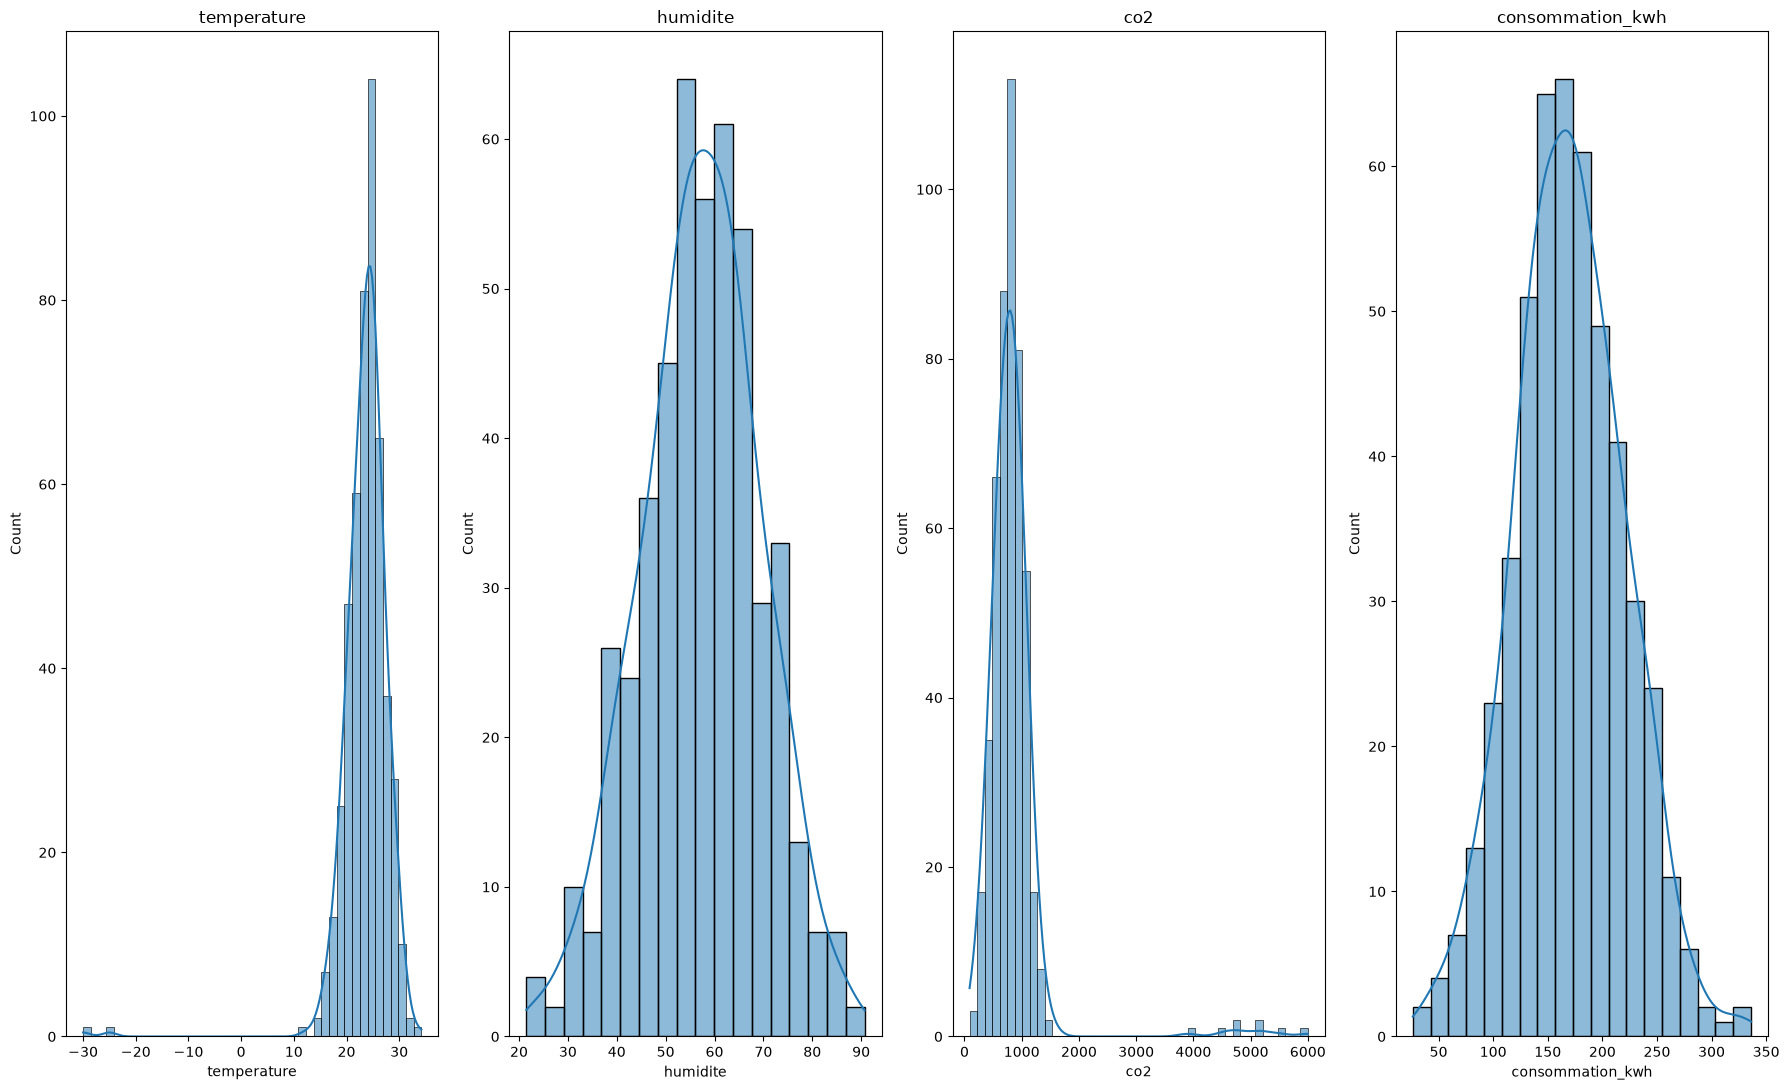

In [78]:
variables = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 11))
for i, col in enumerate(variables):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Réponse a) :** Les quatre variables (`temperature`, `humidite`, `co2`, `consommation_kwh`)
ont des distributions globalement symétriques : les valeurs sont réparties de part et
d'autre de la moyenne, sans asymétrie marquée vers la gauche ou la droite.

**b) La dispersion**

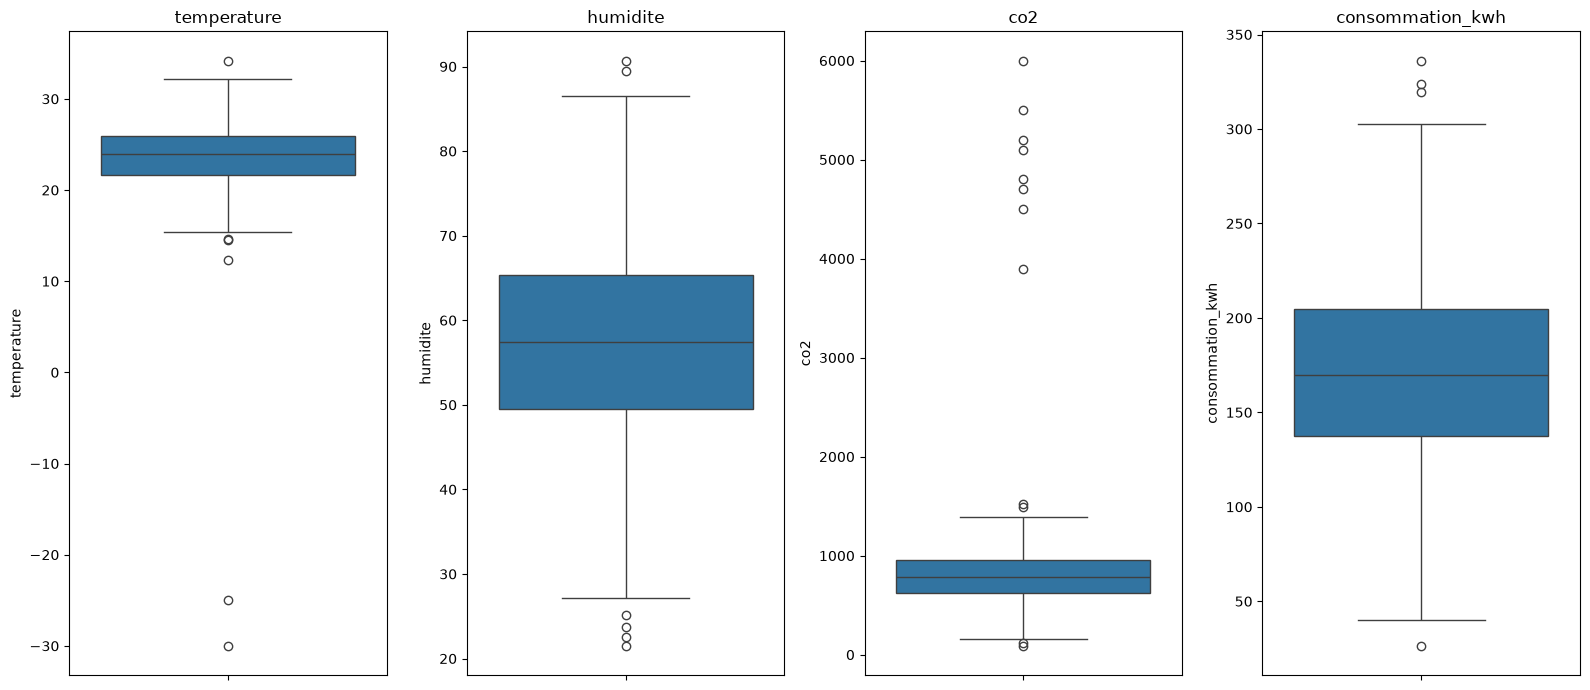

In [76]:
fig, axes = plt.subplots(1, len(variables), figsize=(16, 7))
for i, col in enumerate(variables):
    sns.boxplot(y=df[col].dropna(), ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

 La dispersion diffère nettement selon les variables :

- `temperature` : dispersion faible, la boîte est resserrée (environ 20°C à 30°C), les
  valeurs sont peu étalées autour de la médiane.
- `humidite` : dispersion plus marquée, la boîte s'étend d'environ 50% à 65%.
- `co2` : dispersion faible pour la majorité des données (boîte resserrée autour de
  700-1000), mais avec une moustache haute qui s'étend jusqu'à ~1400.
- `consommation_kwh` : dispersion assez large, la boîte va d'environ 140 à 205 kWh.

`consommation_kwh` et `humidite` sont donc les variables les plus dispersées, tandis que
`temperature` et `co2` sont plus concentrées autour de leur médiane.

**c) Les valeurs extrêmes**

**Réponse c) :** Chaque variable présente des valeurs extrêmes des deux côtés de la distribution :

- `temperature` : valeurs basses extrêmes, autour de -25°C et -30°C, ainsi que deux points
  isolés vers 12-13°C juste sous la moustache basse.
- `humidite` : points hauts isolés autour de 87-90%, et points bas isolés entre 20% et 25%.
- `co2` : points isolés très hauts (jusqu'à environ 6000 ppm), et au moins un point isolé
  très bas proche de 0.
- `consommation_kwh` : un point isolé très bas (environ 10-15 kWh), et au moins un point
  isolé très haut (au-delà de 300 kWh, proche de 335-340).

**d) Les valeurs potentiellement aberrantes**

Parmi les valeurs extrêmes identifiées en c), certaines sont plausibles et
d'autres sont potentiellement aberrantes (probablement des erreurs de capteur) :

- `temperature` : les valeurs négatives extrêmes (-25°C, -30°C) sont très probablement
  aberrantes pour un bâtiment — improbable sans un événement exceptionnel.
- `humidite` : les valeurs à 87-90% et 20-25% restent dans une plage physiquement possible,
  donc probablement des extrêmes réels plutôt qu'aberrants.
- `co2` : les valeurs autour de 5000-6000 ppm sont très élevées par rapport au reste des
  données et potentiellement aberrantes (à ce niveau, l'air serait quasi irrespirable) ;
  une valeur proche de 0 est également suspecte pour un espace occupé.
- `consommation_kwh` : la valeur isolée très basse (~10-15 kWh) et celle très haute
  (~335-340 kWh) sont à vérifier, mais restent moins extrêmes en proportion que celles
  de `co2` et `temperature`.



### 16) Quelle stratégie utiliser pour les valeurs aberrantes ?

**Réponse :** On utilise la méthode de l'IQR (écart interquartile), cohérente avec les
boxplots déjà tracés à la question 15 :

- calcul de Q1 (25e percentile) et Q3 (75e percentile) ;
- IQR = Q3 - Q1 ;
- toute valeur en dehors de [Q1 - 1.5×IQR, Q3 + 1.5×IQR] est considérée comme aberrante.

Plutôt que de supprimer ces lignes (on perdrait de l'information sur les autres colonnes),
on les traite comme des valeurs manquantes (NaN), qui seront imputées avec la même stratégie
que les autres manquants. Cela évite de fausser les statistiques
tout en conservant les observations.

In [80]:
def bornes_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in variables:
    basse, haute = bornes_iqr(df[col])
    n_aberrantes = ((df[col] < basse) | (df[col] > haute)).sum()
    print(f"{col} : bornes [{basse:.1f} ; {haute:.1f}] → {n_aberrantes} valeurs aberrantes")

temperature : bornes [15.2 ; 32.3] → 6 valeurs aberrantes
humidite : bornes [25.8 ; 89.0] → 6 valeurs aberrantes
co2 : bornes [132.0 ; 1444.0] → 12 valeurs aberrantes
consommation_kwh : bornes [36.6 ; 305.4] → 4 valeurs aberrantes


In [81]:
for col in variables:
    basse, haute = bornes_iqr(df[col])
    df.loc[(df[col] < basse) | (df[col] > haute), col] = np.nan

df.isna().sum()

id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           22
humidite              26
co2                   19
occupation             6
consommation_kwh      13
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

### 17) Afficher la fréquence des catégories

**a) Fréquence des bâtiments**

In [82]:
df["batiment"].value_counts()

batiment
b1    92
b5    65
b7    64
b2    60
b4    58
b3    57
b8    53
b6    51
Name: count, dtype: int64

**b) Fréquence des types de bâtiments**

In [84]:
df["type_batiment"].value_counts()

type_batiment
bureau               210
centre commercial     65
école                 59
hôpital               58
entrepôt              52
université            49
ecole                  1
bureu                  1
entrepot               1
Name: count, dtype: int64

**c) Fréquence des modes de climatisation**

In [85]:
df["mode_climatisation"].value_counts()

mode_climatisation
normal     267
eco        130
boost       97
normale      1
Name: count, dtype: int64

**d) Fréquence des états du système**

In [86]:
df["etat_systeme"].value_counts()

etat_systeme
normal    436
alerte     52
panne      12
Name: count, dtype: int64

**e) Fréquence des classes alerte**

In [87]:
df["alerte"].value_counts()

alerte
non    356
oui    144
Name: count, dtype: int64

### 18) Déséquilibre des classes de la variable `alerte`

La variable `alerte` présente un **déséquilibre des classes** :

* **Non** : 356 observations
* **Oui** : 144 observations

La classe **« Non » est donc majoritaire**.


### 19) Corrélation sur les variables numériques

**a) Visualiser la matrice de corrélation avec seaborn**

Text(0.5, 1.0, 'Matrice de corrélation')

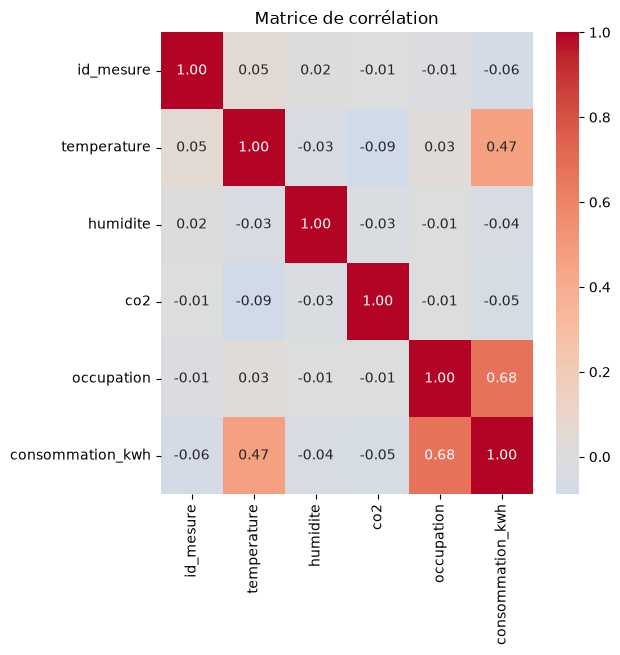

In [104]:
plt.figure(figsize=(6, 6))
matrice_corr = df[variables_numeriques].corr()
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation")


### 19) Identification des corrélations

D’après la matrice de corrélation :

**Corrélations positives :**

* `occupation` et `consommation_kwh` : **0,68** → corrélation positive assez forte.
* `temperature` et `consommation_kwh` : **0,47** → corrélation positive modérée.

**Corrélations négatives :**

* `temperature` et `co2` : **-0,09** → faible corrélation négative.
* `id_mesure` et `consommation_kwh` : **-0,06** → très faible corrélation négative.
* `co2` et `consommation_kwh` : **-0,05** → très faible corrélation négative.
* `humidite` et `consommation_kwh` : **-0,04** → très faible corrélation négative.

**Variables faiblement corrélées :**
La plupart des autres variables ont des coefficients proches de **0**, ce qui indique une faible corrélation linéaire entre elles. Par exemple :

* `temperature` et `humidite` : **-0,03**
* `humidite` et `co2` : **-0,03**
* `occupation` et `humidite` : **-0,01**
* `occupation` et `co2` : **-0,01**

**Conclusion :** la relation la plus importante visible dans la matrice est entre **`occupation` et `consommation_kwh` (0,68)**. Une autre relation positive notable existe entre **`temperature` et `consommation_kwh` (0,47)**. Les autres variables présentent des corrélations faibles ou très faibles.


## Partie 2 – Séparation X / y

**1) Définir la variable "alerte" comme la cible y**

In [106]:
y=df["alerte"]
y.head()

0    non
1    non
2    oui
3    non
4    non
Name: alerte, dtype: str

**2) Trouver des variables explicatives X pertinentes**

On exclut de X :
- `id_mesure` : id_mesure est un identifiant unique et ne représente pas une caractéristique utile pour prédire alerte. Il est donc exclu des variables explicatives X. ;
- `date` : sera éventuellement retravaillée en variables dérivées (jour, mois) plutôt que
  gardée telle quelle ;
- `alerte` : c'est la cible y elle-même, elle ne doit pas apparaître dans X.

In [107]:
X = df.drop(columns=["id_mesure", "date", "alerte"])
X.head()

,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine
0,b8,entrepôt,a,23.0,40.0,851.0,26.0,138.4,eco,normal,jeudi
1,b7,bureau,d,28.0,69.0,538.0,0.0,170.2,eco,normal,lundi
2,b5,centre commercial,b,19.5,52.3,1198.0,64.0,149.8,normal,normal,dimanche
3,b6,université,d,20.0,58.4,1014.0,30.0,141.6,normal,normal,dimanche
4,b7,bureau,d,26.8,70.5,628.0,42.0,228.3,normal,normal,jeudi


In [108]:
y.head()

0    non
1    non
2    oui
3    non
4    non
Name: alerte, dtype: str